In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


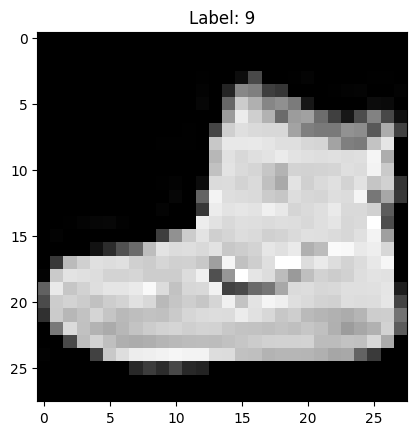

In [2]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [4]:
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

In [5]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(128, activation="relu", input_dim=784))
model.add(Dense(64, activation="relu"))
model.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8216 - loss: 0.5057 - val_accuracy: 0.8472 - val_loss: 0.4166
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8607 - loss: 0.3813 - val_accuracy: 0.8508 - val_loss: 0.4007
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8756 - loss: 0.3409 - val_accuracy: 0.8752 - val_loss: 0.3457
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8825 - loss: 0.3161 - val_accuracy: 0.8724 - val_loss: 0.3507
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8915 - loss: 0.2937 - val_accuracy: 0.8865 - val_loss: 0.3295
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8947 - loss: 0.2816 - val_accuracy: 0.8845 - val_loss: 0.3273
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8988 - loss: 0.2688 - val_accuracy: 0.8857 - val_loss: 0.3206
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9043 - loss: 0.2574 -

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8800 - loss: 0.3506
Test Accuracy: 0.8799999952316284


In [10]:
import numpy as np

predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [11]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = np.argmax(y_test, axis=1)

print(confusion_matrix(y_true, predicted_classes))
print(classification_report(y_true, predicted_classes))

[[857   1  13  32   5   0  85   0   7   0]
 [  3 968   0  22   3   0   3   0   1   0]
 [ 20   1 772   9 128   0  69   0   1   0]
 [ 22   5  17 876  52   0  24   0   4   0]
 [  0   0  79  24 854   0  42   0   1   0]
 [  0   0   0   0   0 941   0  34   5  20]
 [139   1  77  29 108   0 634   0  12   0]
 [  0   0   0   0   0   6   0 970   1  23]
 [  5   0   0   3   5   1   7   4 975   0]
 [  2   0   0   0   0   7   1  37   0 953]]
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.81      0.77      0.79      1000
           3       0.88      0.88      0.88      1000
           4       0.74      0.85      0.79      1000
           5       0.99      0.94      0.96      1000
           6       0.73      0.63      0.68      1000
           7       0.93      0.97      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.96     

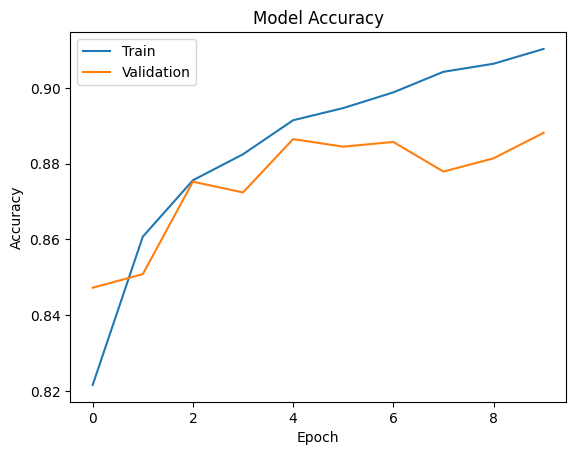

In [12]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()